# Modèle pour la prédiction du débit d'entrée pour la station C

## Imports

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb  
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Données 

ATTENTION AU CHANGEMENT D'HEURE ET METTRE LES DONNÉES EN UTC

In [2]:
# Capteurs
df_sensors = pd.read_csv('/Users/nbieszczad/M2DS/Capstone VINCI/Capstone/Dataset/bronze/sensors_C_20210101_20250101.csv')
df_sensors['ts'] = pd.to_datetime(df_sensors['ts'])

# Débit d'entrée 
df_debit = df_sensors[df_sensors['sensor'] == 'entry_debit'].copy()
df_debit = df_debit.set_index('ts')[['value']].resample('1h').mean() # Le débit est agrégé à l'échelle horaire car les données météo sont à cett échelle.
df_debit.columns = ['debit']

# Météo : dans un premier temps, on va essayer en faisant la moyenne des 14 villes
weather_files = [
    'Aiglemont', 'Chalandry-Elaire', 'Damouzy', 'Dom-le-Mesnil',
    'Flize', 'La-Francheville', 'La-Grandville', 'Les-Ayvelles',
    'Montcy-Notre-Dame', 'Prix-les-Mezieres', 'Saint-Laurent',
    'Ville-sur-Lumes', 'Villers-Semeuse', 'Warcq'
]

weather_frames = []
for city in weather_files:
    try:
        df = pd.read_csv(f'/Users/nbieszczad/M2DS/Capstone VINCI/Capstone/Dataset/bronze/weather_C/{city}_hourly.csv')
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')[['temperature_2m', 'rain', 'wind_speed_10m']].resample('1h').mean()
        weather_frames.append(df)
    except:
        pass

df_weather = pd.concat(weather_frames).groupby(level=0).mean()
if df_weather.index.tz: df_weather.index = df_weather.index.tz_localize(None)

# Fusion
df = pd.merge(df_debit, df_weather, left_index=True, right_index=True, how='inner')


### Features 

In [23]:
# 1. Pluie décalée (LAG 5h) 
df['rain_lag_5'] = df['rain'].shift(5)

# 2. Features temporelles
df['hour'] = df.index.hour
df['month'] = df.index.month

# Encodage cyclique (pour capturer la continuité 23h → 0h). Sans ca, le modele ne pourra pas faire de lien entre 23h et 00H par exemple. 
# Ca va aussi faire que le modele va potentiellement mettre plus de poids sur 23h que 00h car 23>0
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
# Essayer de modéliser la courbe de la tendance de la distribution du débit, et d'avoir un parametre à trouver pour le modèle. 

# 3. Lags du débit (inertie hydraulique)
df['debit_lag_1h'] = df['debit'].shift(1)
df['debit_lag_6h'] = df['debit'].shift(6)                     #Faire la prédiction à 3, 12 et 24h
df['debit_lag_24h'] = df['debit'].shift(24)

# 4. Rolling Statistics (fenêtres glissantes) 
df['debit_roll_mean_24h'] = df['debit'].rolling(window=24, min_periods=1).mean()
df['rain_roll_sum_12h'] = df['rain'].rolling(window=12, min_periods=1).sum()
df['debit_roll_mean_6h'] = df['debit'].rolling(window=6, min_periods=1).mean()
df['rain_roll_sum_6h'] = df['rain'].rolling(window=6, min_periods=1).sum()

# 5. Interactions métier (2eme temps): faire de maniere de plus automatique, polynomial features
# Vaut mieux etre sur avant de mettre ce genre de croisements 
df['temp_x_rain'] = df['temperature_2m'] * df['rain_lag_5']  # Pluie chaude vs froide
df['wind_x_rain'] = df['wind_speed_10m'] * df['rain_lag_5']  # Tempêtes

# 6. Features binaires
#df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)

# Suppression des NaN (dus aux lags)
df_clean = df.dropna()

print(f"Dataset final : {len(df_clean):,} heures")
print(f"Période : {df_clean.index.min()} → {df_clean.index.max()}")
print(f"Features créées : {df_clean.shape[1] - 1} (hors cible)")


Dataset final : 33,368 heures
Période : 2021-01-02 00:00:00 → 2024-12-31 23:00:00
Features créées : 19 (hors cible)


# Prédiction à 3h

## Création des données pour la prédiction à 3h

In [24]:
df_clean['debit_target_3h'] = df_clean['debit'].shift(-3)
df_3h = df_clean.dropna(subset=['debit_target_3h'])

### Split des données et entrainement du modèle sur les différents splits 

Je ne me rappelle pas bien comment utiliser les rolling windows, a partir de quel moment on utilise des choses qu'il ne faut pas.

In [25]:
feature_cols_3h = [
    'temperature_2m', 'wind_speed_10m', 'rain_lag_5',
    #'hour', 'month', 'rain',
    'sin_hour', 'cos_hour', 'sin_month', 'cos_month',
    'debit_lag_6h', 'debit_lag_24h', #'debit_lag_1h', 
    'debit_roll_mean_24h', 'rain_roll_sum_12h', 'debit_roll_mean_6h', 'rain_roll_sum_6h'    
]

X = df_clean[feature_cols_3h]
y = df_clean['debit']

tscv = TimeSeriesSplit(n_splits=5)
results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBRegressor(max_depth=3, n_estimators=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    # Métriques test
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Métriques train
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    results.append({
        'fold': fold+1,
        'rmse_test': rmse_test, 'mae_test': mae_test, 'r2_test': r2_test,
        'rmse_train': rmse_train, 'mae_train': mae_train, 'r2_train': r2_train
    })

    print(f"Fold {fold+1}:")
    print(f"  Train -> RMSE={rmse_train:.2f} | MAE={mae_train:.2f} | R²={r2_train:.3f}")
    print(f"  Test  -> RMSE={rmse_test:.2f} | MAE={mae_test:.2f} | R²={r2_test:.3f}")

# Résumé global
df_results = pd.DataFrame(results)
print("\nRésumé TimeSeriesSplit (moyenne ± std) :")
for metric in ['rmse_train', 'mae_train', 'r2_train', 'rmse_test', 'mae_test', 'r2_test']:
    mean = df_results[metric].mean()
    std = df_results[metric].std()
    print(f"{metric}: {mean:.2f} ± {std:.2f}")

Fold 1:
  Train -> RMSE=19.26 | MAE=13.37 | R²=0.996
  Test  -> RMSE=133.77 | MAE=85.90 | R²=0.860
Fold 2:
  Train -> RMSE=40.03 | MAE=26.78 | R²=0.986
  Test  -> RMSE=166.96 | MAE=107.65 | R²=0.662
Fold 3:
  Train -> RMSE=51.42 | MAE=33.53 | R²=0.979
  Test  -> RMSE=132.77 | MAE=78.22 | R²=0.894
Fold 4:
  Train -> RMSE=61.99 | MAE=39.09 | R²=0.971
  Test  -> RMSE=112.85 | MAE=67.71 | R²=0.898
Fold 5:
  Train -> RMSE=64.82 | MAE=40.36 | R²=0.975
  Test  -> RMSE=113.19 | MAE=69.80 | R²=0.908

Résumé TimeSeriesSplit (moyenne ± std) :
rmse_train: 47.50 ± 18.56
mae_train: 30.63 ± 11.04
r2_train: 0.98 ± 0.01
rmse_test: 131.91 ± 22.06
mae_test: 81.86 ± 16.13
r2_test: 0.84 ± 0.10


Regardons l'importance des features utilisées 

Importance des features (régression linéaire) :
cos_hour              -23.911544
rain_roll_sum_6h       18.289249
rain_lag_5            -13.613654
cos_month               7.962486
sin_month               7.947588
sin_hour                3.895773
rain_roll_sum_12h      -1.586846
debit_roll_mean_6h      1.102384
temperature_2m          0.542855
debit_lag_6h           -0.321879
wind_speed_10m          0.251087
debit_roll_mean_24h     0.121042
debit_lag_24h           0.064967
dtype: float64


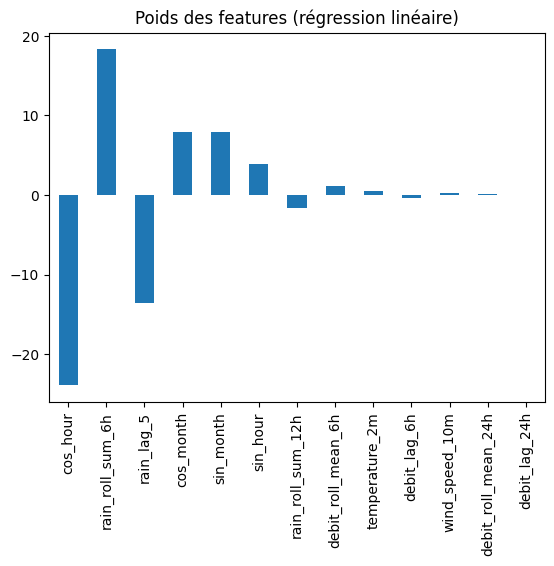

In [26]:
X = df_clean[feature_cols_3h]
y = df_clean['debit']


linreg = LinearRegression()
linreg.fit(X, y)

# Affichage des coefficients
feature_importance = pd.Series(linreg.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Importance des features (régression linéaire) :")
print(feature_importance)

# Visualisation
feature_importance.plot(kind='bar', title="Poids des features (régression linéaire)")
plt.show()

Prochaines étapes, essayer de trouver des indicateurs temporels, tester d'autres fenetres, régulariser le modele,...